# Обучение SegFormer для задачи сегментации повреждений фасада

In [ ]:
!pip install -q transformers evaluate datasets albumentations accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm 
import cv2 
import albumentations as A 
from albumentations.pytorch import ToTensorV2 
from sklearn.metrics import confusion_matrix 
import evaluate 
import wandb 
import warnings
import segmentation_models_pytorch as smp 
import torch
from torch import nn 
from torch.utils.data import Dataset, DataLoader 
from torch.optim.lr_scheduler import CosineAnnealingLR 


device = "cuda" if torch.cuda.is_available() else "cpu"
warnings.filterwarnings('ignore')

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Явно указываем один GPU, чтобы trainer не запускал DDP

## Указываем пути к данным и классы повреждений

In [ ]:
# Пути к папкам
dataset_path = '/kaggle/input/datasets/relplumscalcath/facade-damage-seg-505-imgs-4-cls'  
# Папка с исходными изображениями
image_dir = os.path.join(dataset_path, 'Images') 
# Папка с RGB масками
masks_dir = os.path.join(dataset_path, 'Masks') 

# Маппинг классов
class_mapping = {
    0: "background",
    1: "coating_deterioration",
    2: "masonry_degradation",
    3: "moisture_bio_damage",
    4: "vandalism",
    255: "Ignored" 
}
id2label = class_mapping
label2id = {v: k for k, v in id2label.items()}

cvat_colors_rgb = {
    "background": [0, 0, 0],
    "coating_deterioration": [54, 21, 217],
    "masonry_degradation": [42, 125, 209],
    "moisture_bio_damage": [38, 221, 98],
    "vandalism": [222, 28, 123],
    "Ignored": [221, 255, 51]
}

## Объединяем изображения и маски

In [ ]:
# Прописываем пути к папкам train и val
train_image_dir = os.path.join(dataset_path, 'images', 'train')
train_masks_dir = os.path.join(dataset_path, 'masks', 'train')

val_image_dir = os.path.join(dataset_path, 'images', 'val')
val_masks_dir = os.path.join(dataset_path, 'masks', 'val')

# Объединяем изображения и маски в пары
train_pairs = []
for mask_path in glob(os.path.join(train_masks_dir, "*.png")):
    filename = os.path.basename(mask_path)
    img_path = os.path.join(train_image_dir, filename)
    if os.path.exists(img_path):
        train_pairs.append({"image": img_path, "mask": mask_path})

val_pairs = []
for mask_path in glob(os.path.join(val_masks_dir, "*.png")):
    filename = os.path.basename(mask_path)
    img_path = os.path.join(val_image_dir, filename)
    if os.path.exists(img_path):
        val_pairs.append({"image": img_path, "mask": mask_path})

# Final Fit (обучение на всей выборке train + val)
all_pairs = train_pairs + val_pairs

# Проверяем размер получившихся выборок
print(f"Обучающая выборка: {len(train_pairs)}")
print(f"Валидационная выборка: {len(val_pairs)}")

Обучающая выборка: 403
Валидационная выборка: 102


## Создаем класс Dataset и применяем аугментации

In [ ]:
class DamageSegmentationDataset(Dataset):
    def __init__(self, dataset_pairs, transform=None):
        self.dataset_pairs = dataset_pairs
        self.transform = transform
        # Нормируем картинки под SegFormer
        self.processor = SegformerImageProcessor.from_pretrained("nvidia/mit-b2")

    def __len__(self):
        return len(self.dataset_pairs)

    def __getitem__(self, idx):
        pair = self.dataset_pairs[idx]        
        # Считываем изображение 
        image = cv2.imread(pair["image"])
        # Конвертируем в RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)        
        # Считываем маску
        mask = cv2.imread(pair["mask"], cv2.IMREAD_GRAYSCALE)        
        # Применяем аугментации
        if self.transform is not None:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        # Делаем ресайз и нормализацию    
        inputs = self.processor(images=Image.fromarray(image), segmentation_maps=mask, return_tensors="pt")        
        # Убираем лишнюю размерность batch
        inputs = {k: v.squeeze() for k, v in inputs.items()}
        
        return inputs

# Аугментации для train (только финальный вариант). 
# Экспериментальные варианты удалены
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
])

val_transform = None

# Создаем датасеты
train_dataset = DamageSegmentationDataset(train_pairs, transform=train_transform)
val_dataset = DamageSegmentationDataset(val_pairs, transform=val_transform)

all_data = DamageSegmentationDataset(all_pairs, transform=train_transform)

preprocessor_config.json:   0%|          | 0.00/272 [00:00<?, ?B/s]

## Добавляем веса классов для функции потерь

У нас сильный дисбаланс, поэтому мы вычислим веса для CrossEntropyLoss, чтобы штрафовать редкие классы сильнее.

In [ ]:
# Веса рассчитаны скриптом caclulate_stats.py на всем объединенном датасете при помощи Median Frequency Balancing отдельным скриптом calculate_stats.py
weights = [0.0836, 0.6757, 6.8733, 1.0000, 8.0189]

class_weights_tensor = torch.tensor(weights, dtype=torch.float).to(device)
print("Веса классов для CrossEntropyLoss:")
for i, w in enumerate(weights):
    print(f"Класс {id2label[i]}: {w:.4f}")

Веса классов для CrossEntropyLoss:
Класс background: 0.0836
Класс coating_deterioration: 0.6757
Класс masonry_degradation: 6.8733
Класс moisture_bio_damage: 1.0000
Класс vandalism: 8.0189


## Инициализируем wandb

In [7]:
wandb.login() 
wandb.init(project="facade-damage-segformer", name="SegFormer-B3-505-imgs-4-cls-ff")

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rimedheart (rimedheart-personal-use) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Создаем модель и задаем вычисление метрик

In [ ]:
# Используем модифицированный класс Weightedtrainer, чтобы передать наши веса в функцию потерь
class ClassWeightstrainer(trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # SegFormer выдаёт логиты в 4 раза меньше оригинала, плэтому растягиваем обратно
        upsampled_logits = nn.functional.interpolate(
            logits,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        # исключаем пиксели класса Ignored из расчёта функции потерь
        loss_fct = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=255)
        loss = loss_fct(upsampled_logits, labels)

        return (loss, outputs) if return_outputs else loss


metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
    with torch.no_grad():
        logits, labels = eval_pred
        logits_tensor = torch.from_numpy(logits)

        logits_tensor = nn.functional.interpolate(
            logits_tensor,
            size=labels.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).argmax(dim=1)

        pred_labels = logits_tensor.detach().cpu().numpy()

        metrics = metric.compute(
            predictions=pred_labels,
            references=labels,
            num_labels=len(id2label) - 1,
            ignore_index=255,
            reduce_labels=False,
        )

        safe_metrics = {}

        for key in ("mean_iou", "mean_accuracy", "overall_accuracy"):
            if key in metrics:
                safe_metrics[key] = float(metrics[key])

        # IoU по каждому классу
        if "per_category_iou" in metrics:
            vals = metrics["per_category_iou"]
            if isinstance(vals, np.ndarray):
                vals = vals.tolist()
            for i, val in enumerate(vals):
                if i < len(id2label) - 1:
                    safe_metrics[f"iou_{id2label[i]}"] = float(val) if not np.isnan(val) else 0.0
    
    return safe_metrics

# Задаем модель
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/mit-b2",
    num_labels=len(id2label) - 1,
    id2label={k: v for k, v in id2label.items() if k != 255},
    label2id={v: k for k, v in id2label.items() if k != 255},
    ignore_mismatched_sizes=True
)

## Задаем параметры обучения

In [ ]:
training_args = trainingArguments(
    output_dir="/kaggle/working/segformer-b2-facade-damage",
    report_to="wandb",
    learning_rate=6e-5,
    num_train_epochs=50, # датасет маленький, поэтому хватает и небольшого количества эпох
    
    per_device_train_batch_size=4,  # С бОльшим размером батча получаю Out of Memory,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=2,  # Накапливаем градиенты, чтобы компенсировать мальенький батч 
    
    dataloader_num_workers=0,       
    eval_accumulation_steps=1,      
    
    eval_strategy="epoch",
    save_strategy="epoch",          
    save_total_limit=1,             
    load_best_model_at_end=True,    
    metric_for_best_model="mean_iou",
)


trainer = ClassWeightstrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

Аргументы для Final Fit на всей выборке: train + val

In [ ]:
training_args = trainingArguments(
    output_dir='./segformer-b2-final-model',
    num_train_epochs=50,             
    per_device_train_batch_size=4, 
    gradient_accumulation_steps=2,
    learning_rate=6e-5,              
    
    # Настройки сохранения и логирования:
    logging_strategy="epoch", # Логируем Loss только для train
    save_strategy="epoch",           
    save_total_limit=2,              
    
    # Отключаем валидцию
    eval_strategy="no",      
    load_best_model_at_end=False
)

trainer = ClassWeightstrainer(
    model=model,
    args=training_args,
    train_dataset=all_data,
    compute_metrics=compute_metrics,
)

## Запускаем обучение

In [ ]:
trainer.train()

## Анализ результатов

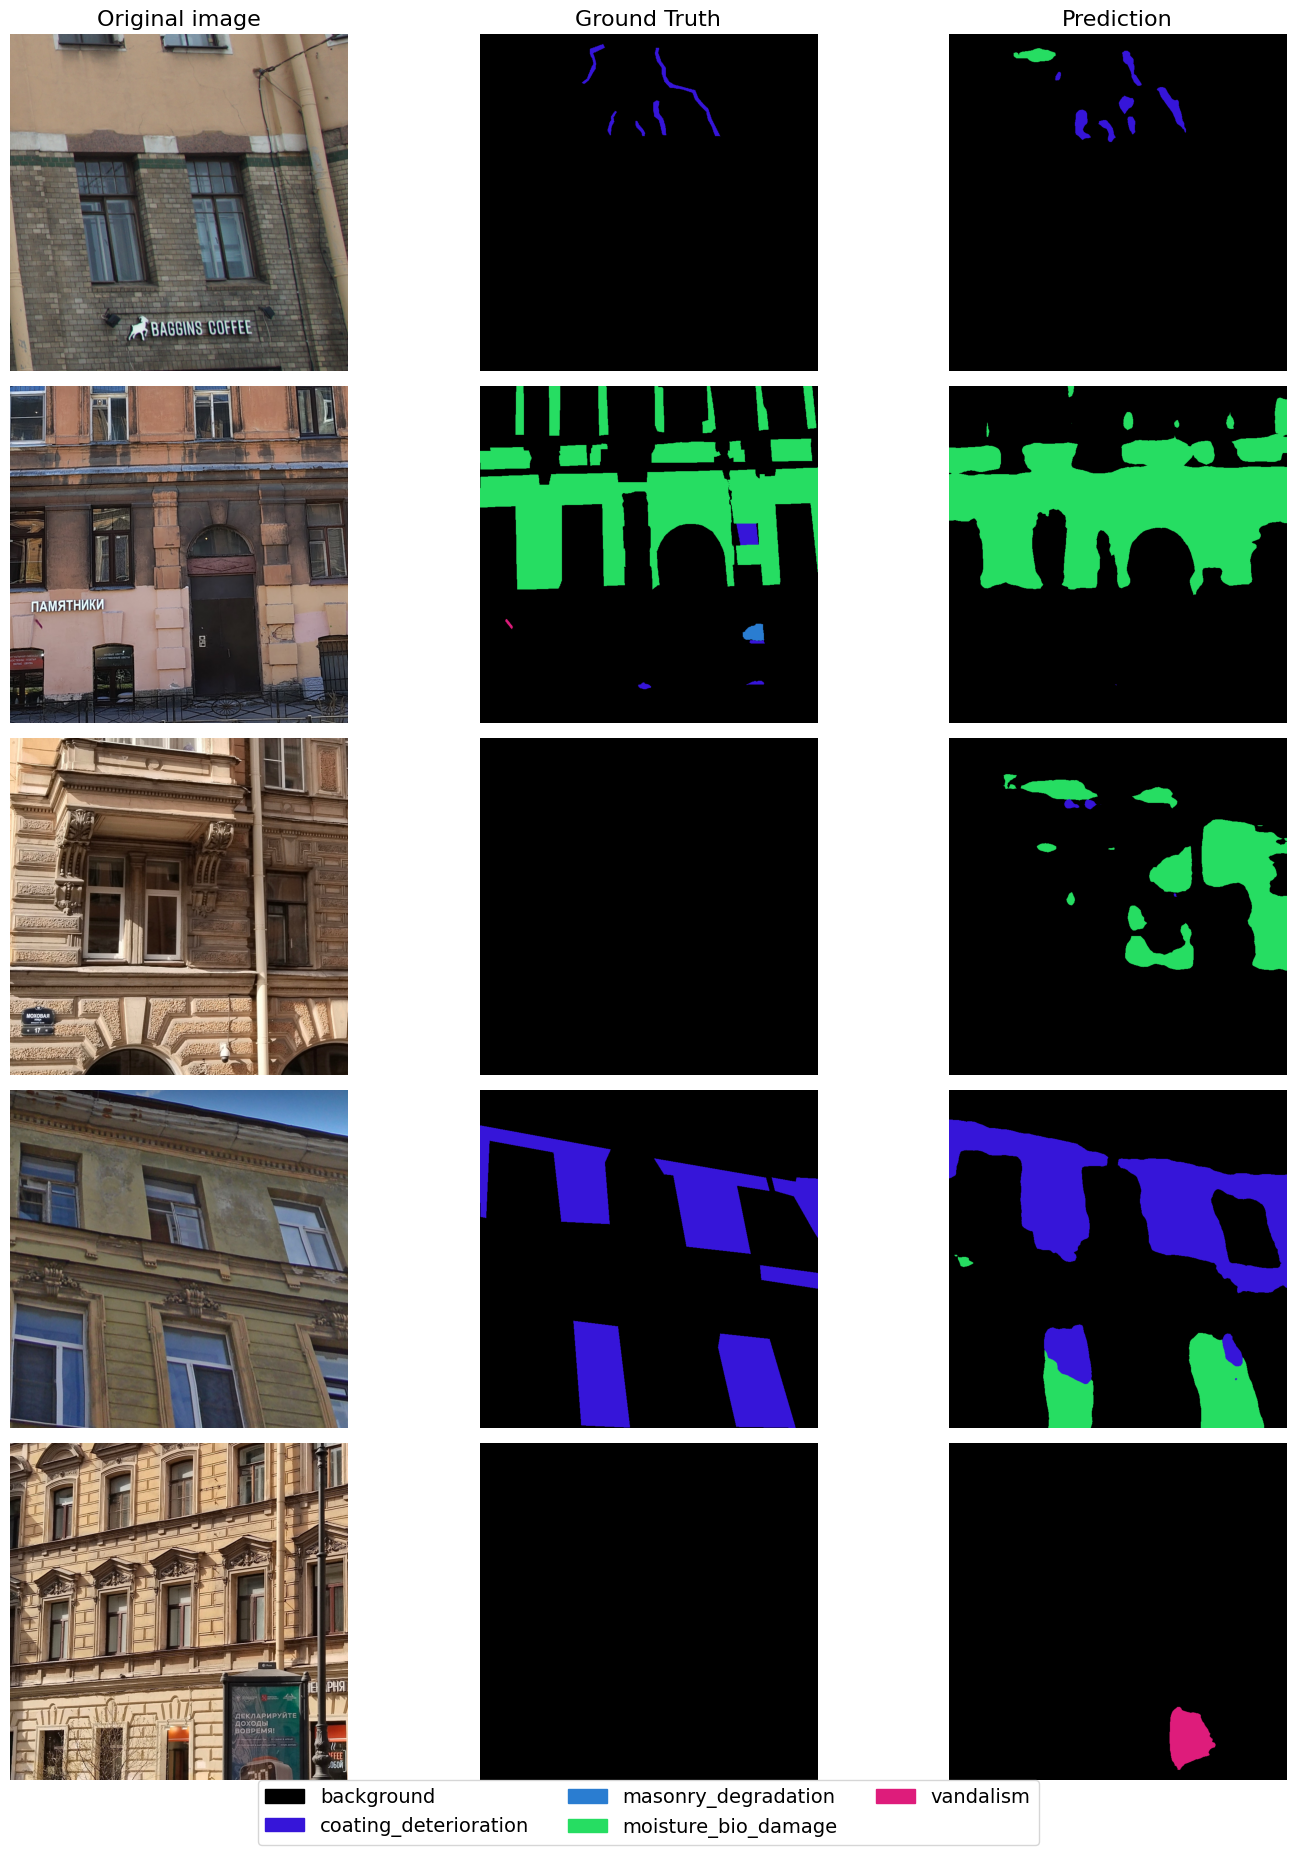

In [ ]:
# Задаем такие же цвета, как у масок
color_map = {
    0: (0, 0, 0), # background
    1: (54, 21, 217), # coating_deterioration
    2: (42, 125, 209), # masonry_degradation
    3: (38, 221, 98), # moisture_bio_damage
    4: (222, 28, 123) # vandalism
}

def label_to_color_image(label_mask):
    color_img = np.zeros((label_mask.shape[0], label_mask.shape[1], 3), dtype=np.uint8)
    for class_id, color in color_map.items():
        color_img[label_mask == class_id] = color
    return color_img

# выбираем 5 случайных фасадов
sample_indices = random.sample(range(len(val_pairs)), 5)
# и строим для них GT и полученные маски
fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes[0, 0].set_title("Original image", fontsize=16)
axes[0, 1].set_title("Ground Truth", fontsize=16)
axes[0, 2].set_title("Prediction", fontsize=16)

model.eval()

with torch.no_grad():
    for i, idx in enumerate(sample_indices):
        pair = val_pairs[idx]

        orig_img = cv2.imread(pair["image"])
        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

        inputs = val_dataset[idx]
        input_tensor = inputs["pixel_values"].unsqueeze(0).to(device)

        gt_mask = cv2.imread(pair["mask"], cv2.IMREAD_GRAYSCALE)

        outputs = model(pixel_values=input_tensor)
        upsampled_logits = torch.nn.functional.interpolate(
            outputs.logits,
            size=orig_img.shape[:2],
            mode="bilinear",
            align_corners=False
        )
        pred_mask = upsampled_logits.argmax(dim=1).squeeze().cpu().numpy()

        axes[i, 0].imshow(orig_img);        axes[i, 0].axis("off")
        axes[i, 1].imshow(label_to_color_image(gt_mask));   axes[i, 1].axis("off")
        axes[i, 2].imshow(label_to_color_image(pred_mask)); axes[i, 2].axis("off")

patches = [mpatches.Patch(color=np.array(color)/255.0, label=class_mapping[idx])
           for idx, color in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, 0.02), fontsize=14)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [ ]:
def evaluate_segmentation(model, val_dataset, val_pairs, device, class_mapping, is_unet=False):
    """Функция для построения Confusion matrix и IoU по классам на валидационной выборке"""
    working_classes = [k for k in class_mapping if k != 255]
    class_names     = [class_mapping[i] for i in working_classes]
    # Создаем пустую матрицу ошибок
    total_cm = np.zeros((len(working_classes), len(working_classes)), dtype=np.int64)

    model.eval()
    with torch.no_grad():
        for idx in tqdm(range(len(val_pairs))):
            gt_mask      = cv2.imread(val_pairs[idx]["mask"], cv2.IMREAD_GRAYSCALE)
            input_tensor = val_dataset[idx]["pixel_values"].unsqueeze(0).to(device)

            if is_unet:
                raw_logits = model(input_tensor)
            else:
                raw_logits = model(pixel_values=input_tensor).logits
            # Растягиваем до размера нашей оригинальной маски,
            logits = nn.functional.interpolate(
                raw_logits,
                size=gt_mask.shape[:2],
                mode="bilinear",
                align_corners=False
            )
            # Получаем предсказанную маску
            pred_mask = logits.argmax(dim=1).squeeze().cpu().numpy()
            # Добавлем ее к матрице ошибок
            total_cm += confusion_matrix(
                gt_mask.flatten(), pred_mask.flatten(), labels=working_classes
            )
    # Нормализуем матрицу ошибок.
    cm_norm = np.nan_to_num(total_cm.astype('float') / total_cm.sum(axis=1)[:, np.newaxis])

    # Визаализация
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Доля пикселей'})
    plt.title("Матрица ошибок\n", fontsize=15)
    plt.ylabel('Истинный класс', fontsize=12, fontweight='bold')
    plt.xlabel('Предсказанный класс', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Считаем метрики IoU
    intersection = np.diag(total_cm)
    union = total_cm.sum(axis=1) + total_cm.sum(axis=0) - intersection
    ious  = intersection / union.astype(np.float32)

    print("\nIoU по классам:")
    for name, iou in zip(class_names, ious):
        print(f"  {name.ljust(25)}: {iou:.4f}")
    print(f"  {'Mean IoU'.ljust(25)}: {np.nanmean(ious):.4f}")

  0%|          | 0/102 [00:00<?, ?it/s]

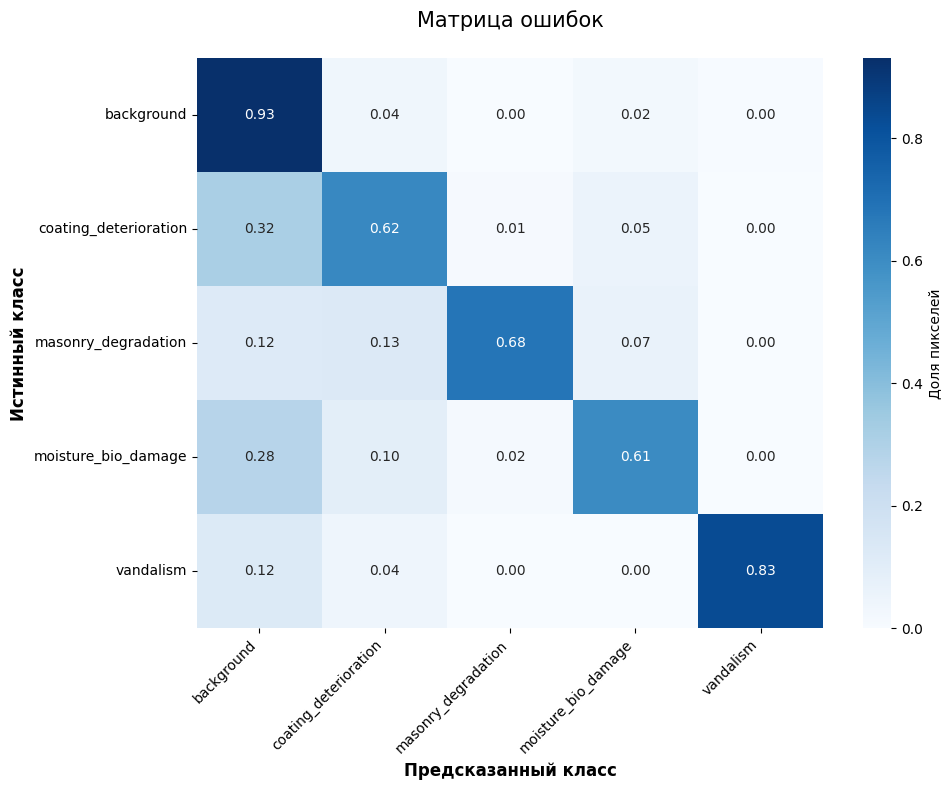


IoU по классам:
  background               : 0.8723
  coating_deterioration    : 0.4450
  masonry_degradation      : 0.4671
  moisture_bio_damage      : 0.4415
  vandalism                : 0.6018
  Mean IoU                 : 0.5656


In [ ]:
# SegFormer
evaluate_segmentation(model, val_dataset, val_pairs, device, class_mapping)

## Бейзлайн: U-Net (ResNet-34)

Для сравнения обучим U-Net с энкодером ResNet-34

In [20]:
!pip install -q segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
wandb.init(project="facade-damage-segformer", name="U-Net-505-imgs-4-cls-final")

In [ ]:
# Освобождаем память SegFormer перед загрузкой U-Net
del trainer
torch.cuda.empty_cache()

In [ ]:
num_epochs = 50

unet = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=len(id2label) - 1
).to(device)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=4, shuffle=False, num_workers=0)

optimizer = torch.optim.AdamW(unet.parameters(), lr=6e-5)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=255)

best_miou_unet  = 0.0
best_state_unet = None

wandb.define_metric("*", step_metric="epoch")

metric = evaluate.load("mean_iou")

for epoch in range(num_epochs):
    unet.train()
    total_loss = 0.0
    for batch in train_loader:
        pixel_values = batch["pixel_values"].to(device)
        labels       = batch["labels"].to(device)
        
        loss = criterion(unet(pixel_values), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    scheduler.step()

    # Валидация
    unet.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in val_loader:
            preds = unet(batch["pixel_values"].to(device)).argmax(dim=1).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(batch["labels"].numpy())
    # Считаем метрики (в данном случае mIoU) для всех собранных предсказаний
    result = metric.compute(
        predictions=np.concatenate(all_preds), # Объединяем все предсказания
        references=np.concatenate(all_labels), # Объединяем все правильные ответы
        num_labels=len(id2label) - 1,
        ignore_index=255, # Игнорируем фон
        reduce_labels=False
    )
    # Получаем значение среднего IoU
    val_miou = float(result["mean_iou"])
    # Проверяем, стал ли текущий mIoU лучше, чем предыдущий лучший
    if val_miou > best_miou_unet:
        # обновляем лучший mIoU
        best_miou_unet  = val_miou
        # Сохраняем параметры лучшей модели
        best_state_unet = {k: v.cpu().clone() for k, v in unet.state_dict().items()}

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1:02d}/{num_epochs}  loss={avg_loss:.4f}  val_mIoU={val_miou:.4f}")
    # словарь с метриками для записи в wandb
    log_dict = {
        "train/loss":    avg_loss,
        "eval/mean_iou": val_miou,
        "epoch":         epoch + 1
    }
    # Добавляем IoU для каждого отдельного класса
    for i, iou_val in enumerate(result["per_category_iou"].tolist()):
        if i < len(id2label) - 1:
            log_dict[f"eval/iou_{id2label[i]}"] = 0.0 if np.isnan(iou_val) else float(iou_val)
    wandb.log(log_dict) # логируем 


print(f"Лучший val mIoU U-Net: {best_miou_unet:.4f}")
unet.load_state_dict(best_state_unet)
wandb.finish()

  0%|          | 0/102 [00:00<?, ?it/s]

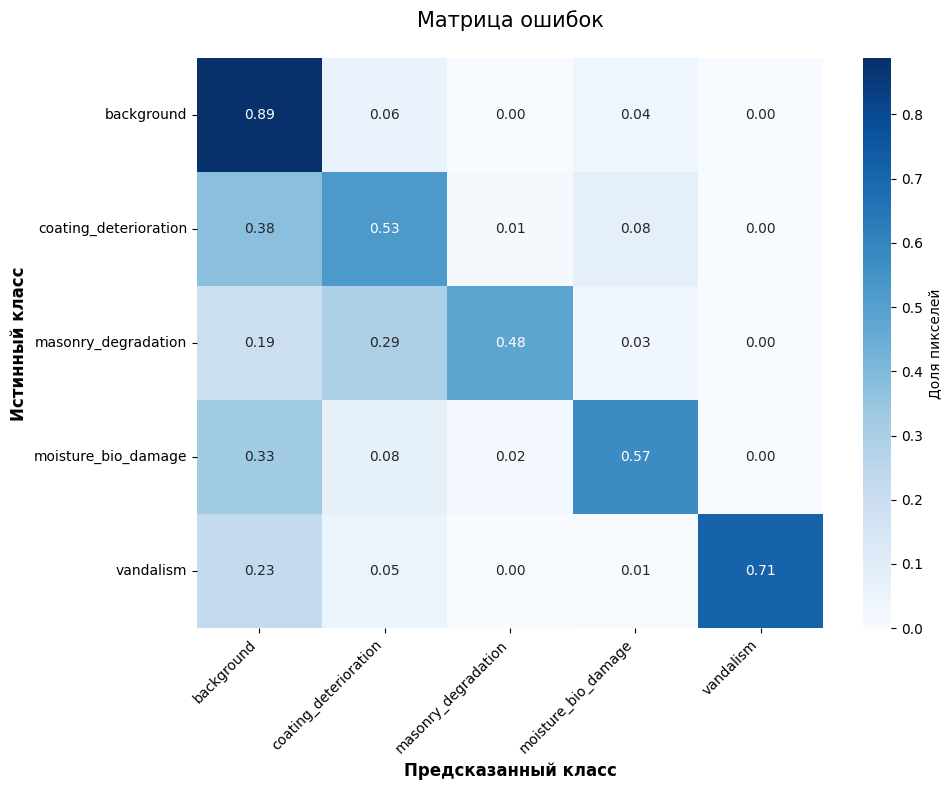


IoU по классам:
  background               : 0.8211
  coating_deterioration    : 0.3354
  masonry_degradation      : 0.3136
  moisture_bio_damage      : 0.3487
  vandalism                : 0.5262
  Mean IoU                 : 0.4690


In [ ]:
# Выводим результаты для U-Net
evaluate_segmentation(unet, val_dataset, val_pairs, device, class_mapping, is_unet=True)


Видно, что U-Net показал худшие результаты по всем классам. Значит, в качестве основной модели для дальнейшей работы будем использовать SegFormer-B2